In [1]:
import nest_asyncio

nest_asyncio.apply()

import sys

sys.path.append("../")

from dotenv import load_dotenv

assert load_dotenv("../.env", override=True), "failed to load .env"

In [2]:
import os
from qdrant_client import QdrantClient
from crystalvision.lang.embeddings import FastEmbedEmbeddingsGPU
from fastembed import ImageEmbedding


qclient = QdrantClient(prefer_grpc=True, url="localhost")

COLLECTION_NAME = "test_images_texts_gpu"

ImageEmbedding.list_supported_models()

[{'model': 'Qdrant/clip-ViT-B-32-vision',
  'sources': {'hf': 'Qdrant/clip-ViT-B-32-vision', 'url': None},
  'model_file': 'model.onnx',
  'description': 'Image embeddings, Multimodal (text&image), 2021 year',
  'license': 'mit',
  'size_in_GB': 0.34,
  'additional_files': [],
  'dim': 512,
  'tasks': {}},
 {'model': 'Qdrant/resnet50-onnx',
  'sources': {'hf': 'Qdrant/resnet50-onnx', 'url': None},
  'model_file': 'model.onnx',
  'description': 'Image embeddings, Unimodal (image), 2016 year',
  'license': 'apache-2.0',
  'size_in_GB': 0.1,
  'additional_files': [],
  'dim': 2048,
  'tasks': {}},
 {'model': 'Qdrant/Unicom-ViT-B-16',
  'sources': {'hf': 'Qdrant/Unicom-ViT-B-16', 'url': None},
  'model_file': 'model.onnx',
  'description': 'Image embeddings (more detailed than Unicom-ViT-B-32), Multimodal (text&image), 2023 year',
  'license': 'apache-2.0',
  'size_in_GB': 0.82,
  'additional_files': [],
  'dim': 768,
  'tasks': {}},
 {'model': 'Qdrant/Unicom-ViT-B-32',
  'sources': {'hf':

In [3]:
embedding = FastEmbedEmbeddingsGPU(
    model_name=os.getenv("FASTEMBED_IMAGE_MODEL"), mtype="image"
)
text_embedding = FastEmbedEmbeddingsGPU(
    model_name=os.getenv("FASTEMBED_TEXT_MODEL"), mtype="text"
)

2025-03-06 22:22:23.994267796 [W:onnxruntime:, session_state.cc:1168 VerifyEachNodeIsAssignedToAnEp] Some nodes were not assigned to the preferred execution providers which may or may not have an negative impact on performance. e.g. ORT explicitly assigns shape related ops to CPU to improve perf.
2025-03-06 22:22:23.994309527 [W:onnxruntime:, session_state.cc:1170 VerifyEachNodeIsAssignedToAnEp] Rerunning with verbose output on a non-minimal build will show node assignments.
2025-03-06 22:22:25.585726911 [W:onnxruntime:, session_state.cc:1168 VerifyEachNodeIsAssignedToAnEp] Some nodes were not assigned to the preferred execution providers which may or may not have an negative impact on performance. e.g. ORT explicitly assigns shape related ops to CPU to improve perf.
2025-03-06 22:22:25.585767888 [W:onnxruntime:, session_state.cc:1170 VerifyEachNodeIsAssignedToAnEp] Rerunning with verbose output on a non-minimal build will show node assignments.


In [4]:
from crystalvision.lang.loaders import explain_database

df = explain_database(False)
df.head(3)

,code,rarity,cost,category_1,category_2,ex_burst,set,name_en,type_en,job_en,text_en,images,illustrator,limit_break,icons,element_ja,power,element,numElements
0,1-001H,H,6,X,None,False,[Opus I],Auron,Forward,Guardian,"When Auron deals damage to your opponent, you ...","[1-001H_eg.jpg, 1-001H_de.jpg, 1-001H_es.jpg, ...",NaN,False,NaN,"(火,)",9000.0,{Fire},1
1,1-002R,R,5,X,None,False,[Opus I],Auron,Forward,Guardian,The Backups you control cannot be broken by yo...,"[1-002R_eg.jpg, 1-002R_de.jpg, 1-002R_es.jpg, ...",NaN,False,NaN,"(火,)",9000.0,{Fire},1
2,1-003C,C,2,III,None,False,[Opus I],Red Mage,Backup,Standard Unit,《火》《1》《ダル》: Choose 1 Forward. It cannot block ...,"[1-003C_eg.jpg, 1-003C_de.jpg, 1-003C_es.jpg, ...",NaN,False,multicard,"(火,)",NaN,{Fire},1


In [5]:
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

In [6]:
from crystalvision.data.base import DATA_DIR


def series_chain(iterables):
    for iterable in iterables.values:
        for i in iterable:
            yield DATA_DIR / "img" / i


df = df.explode("images").query("images.str.endswith('_eg.jpg')")
df["image_url"] = "https://fftcg.cdn.sewest.net/images/cards/full/" + df["images"]
df["file_name"] = str(DATA_DIR / "img") + "/" + df["images"]

In [7]:
df["file_cached"] = df["file_name"].apply(os.path.exists)
df = df[df["file_cached"] == True]

In [8]:
df["set"] = df["set"].apply(lambda x: x if not isinstance(x, list) else ", ".join(x))
df["set"].unique()

array(['Opus I', 'Opus X', 'Opus XI', 'Opus XII', 'Opus XIII', 'Opus XIV',
       'Crystal Dominion', 'Crystal Dominion, Hidden Trials',
       'Emissaries of Light', 'Emissaries of Light, Hidden Hope',
       "Rebellion's Call", 'Resurgence of Power',
       'Resurgence of Power, Hidden Hope', 'From Nightmares',
       'From Nightmares, Hidden Trials', 'Opus II', 'Dawn of Heroes',
       'Beyond Destiny', 'Dissidia Collection Set', 'Hidden Hope',
       'Hidden Trials', 'Hidden Legends', 'Opus III', 'Opus IV',
       'Opus IV, Hidden Hope', 'Opus V', 'Opus VI', 'Opus VII',
       'Opus VIII', 'Opus IX', 'Boss Deck Chaos', 'Boss Deck FFVII',
       'Legacy Collection'], dtype=object)

In [9]:
from jinja2 import Environment, FileSystemLoader, Template, select_autoescape
from crystalvision.lang import CORPUS_DIR


JENV = Environment(
    loader=FileSystemLoader(CORPUS_DIR / ".." / "jtemplate"),
    autoescape=select_autoescape(),
)

template: Template = JENV.get_template("cards.jinja")

df["description"] = df.swifter.apply(lambda row: template.render(**row), axis=1)

/home/acbaraka/.cache/pypoetry/virtualenvs/crystalvision-4sHt3Jis-py3.11/lib/python3.11/site-packages/swifter/swifter.py:87: UserWarning: This pandas object has duplicate indices, and swifter may not be able to improve performance. Consider resetting the indices with `df.reset_index(drop=True)`.
  warnings.warn(


Pandas Apply:   0%|          | 0/3709 [00:00<?, ?it/s]

In [10]:
df.head(3)

,code,rarity,cost,category_1,category_2,ex_burst,set,name_en,type_en,job_en,text_en,images,illustrator,limit_break,icons,element_ja,power,element,numElements,image_url,file_name,file_cached,description
0,1-001H,H,6,X,None,False,Opus I,Auron,Forward,Guardian,"When Auron deals damage to your opponent, you may play 1 Fire Backup from your hand onto the field dull.",1-001H_eg.jpg,NaN,False,NaN,"(火,)",9000.0,{Fire},1,https://fftcg.cdn.sewest.net/images/cards/full/1-001H_eg.jpg,/mnt/d/CrystalVision/data/img/1-001H_eg.jpg,True,"The card with code/serial 1-001H has the name Auron, of type Forward, the job Guardian, with 9000.0 power, costs 6, and is the element(s) Fire. \n\nIt reads as follows:\nWhen Auron deals damage to your opponent, you may play 1 Fire Backup from your hand onto the field dull."
1,1-002R,R,5,X,None,False,Opus I,Auron,Forward,Guardian,The Backups you control cannot be broken by your opponent's Summons or abilities.,1-002R_eg.jpg,NaN,False,NaN,"(火,)",9000.0,{Fire},1,https://fftcg.cdn.sewest.net/images/cards/full/1-002R_eg.jpg,/mnt/d/CrystalVision/data/img/1-002R_eg.jpg,True,"The card with code/serial 1-002R has the name Auron, of type Forward, the job Guardian, with 9000.0 power, costs 5, and is the element(s) Fire. \n\nIt reads as follows:\nThe Backups you control cannot be broken by your opponent's Summons or abilities."
2,1-003C,C,2,III,None,False,Opus I,Red Mage,Backup,Standard Unit,《火》《1》《ダル》: Choose 1 Forward. It cannot block this turn.,1-003C_eg.jpg,NaN,False,multicard,"(火,)",NaN,{Fire},1,https://fftcg.cdn.sewest.net/images/cards/full/1-003C_eg.jpg,/mnt/d/CrystalVision/data/img/1-003C_eg.jpg,True,"The card with code/serial 1-003C has the name Red Mage, of type Backup, the job Standard Unit, costs 2, and is the element(s) Fire. \n\nIt reads as follows:\n《火》《1》《ダル》: Choose 1 Forward. It cannot block this turn."


In [11]:
from uuid import uuid5, NAMESPACE_URL
from qdrant_client import models as qmodels


if not qclient.collection_exists(collection_name=COLLECTION_NAME):
    distance = qmodels.Distance.COSINE
    embedding_vector = list(embedding.model.embed(DATA_DIR / "img" / "PR-001_eg.jpg"))[
        0
    ]
    text_embedding_vector = list(
        text_embedding.model.embed("Getting the dimesionality!")
    )[0]
    qclient.create_collection(
        collection_name=COLLECTION_NAME,
        vectors_config={
            "image": qmodels.VectorParams(
                size=embedding_vector.shape[0], distance=distance
            ),
            "text": qmodels.VectorParams(
                size=len(text_embedding_vector), distance=distance
            ),
        },
    )

df.groupby("set").apply(
    lambda sub_df: qclient.upsert(
        collection_name=COLLECTION_NAME,
        points=[
            qmodels.PointStruct(
                id=str(uuid5(NAMESPACE_URL, row["image_url"])),
                vector={"image": vector, "text": text_vector},
                payload={
                    "image_url": row["image_url"],
                    "set": row["set"],
                    "file_name": row["images"],
                    "name": row["name_en"],
                    "type": row["type_en"],
                    "element": list(row["element"]),
                    "icons": row["icons"] if not pd.isna(row["icons"]) else None,
                    "job": row["job_en"] if row["job_en"] else None,
                    "power": int(row["power"]) if not pd.isna(row["power"]) else None,
                },
            )
            for (_, row), vector, text_vector in zip(
                sub_df.iterrows(),
                embedding.model.embed(sub_df["file_name"]),
                text_embedding.model.embed(sub_df["description"]),
            )
        ],
    )
)

qclient.count(COLLECTION_NAME).count

/tmp/ipykernel_34216/665237746.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("set").apply(lambda sub_df:


3709

In [27]:
from pathlib import Path
from IPython.display import Image
import matplotlib.pyplot as plt
from PIL import Image as PImage


def find_similar_image(search_img: Path, collection_name: str = COLLECTION_NAME):
    query_vector = list(embedding.model.embed(search_img))[0]

    results = qclient.query_points(
        collection_name=COLLECTION_NAME, query=query_vector, using="image"
    ).points

    # Create the plot
    fig, axes = plt.subplots(2, 5)
    axes = axes.flatten()  # Flatten axes for easy iteration

    for i, r in enumerate(results):
        try:
            # Fetch and load image
            img = PImage.open(DATA_DIR / "img" / r.payload["file_name"])

            # Display the image
            axes[i].imshow(img)
            axes[i].set_title(f"{r.score:.3f}")
            axes[i].axis("off")  # Turn off axes for a cleaner look
        except Exception:
            axes[i].text(0.5, 0.5, "Image not available", ha="center", va="center")
            axes[i].axis("off")

    # Hide any extra subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()

    return Image(search_img), plt

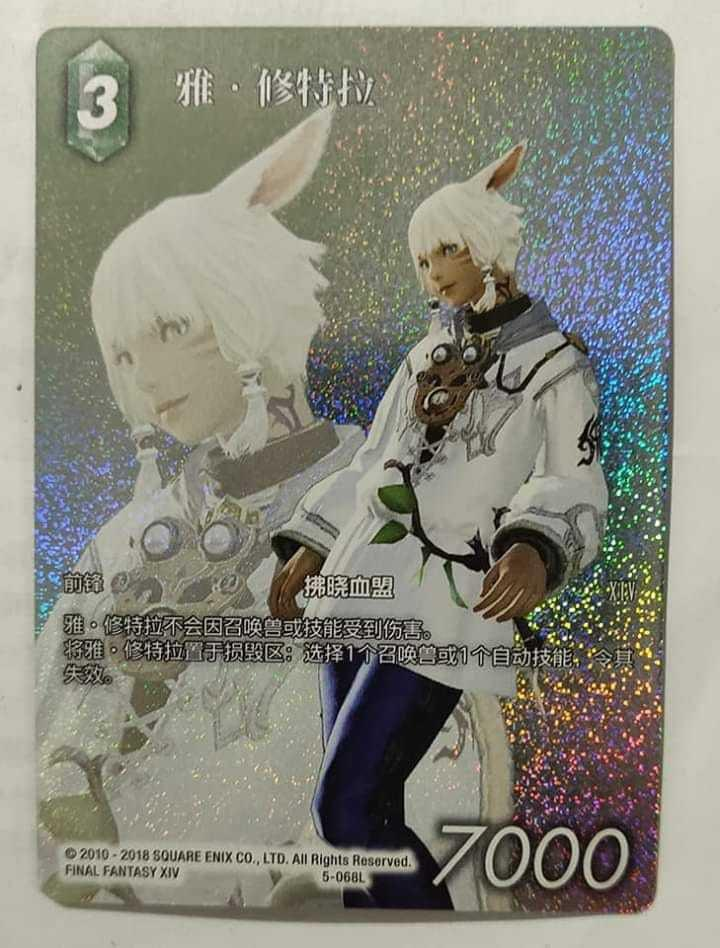

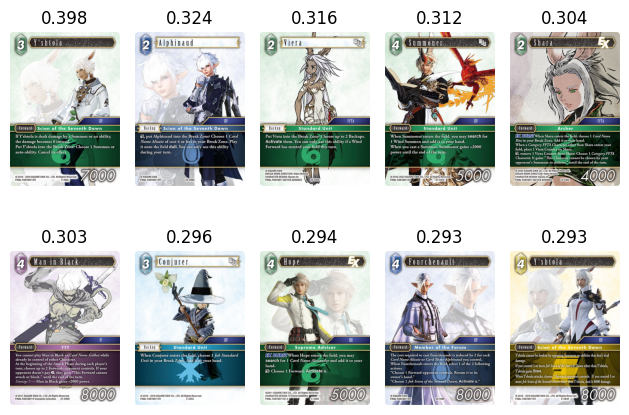

In [28]:
img, plt = find_similar_image(DATA_DIR / "test" / "4.jpg")
img

In [29]:
plt.show()

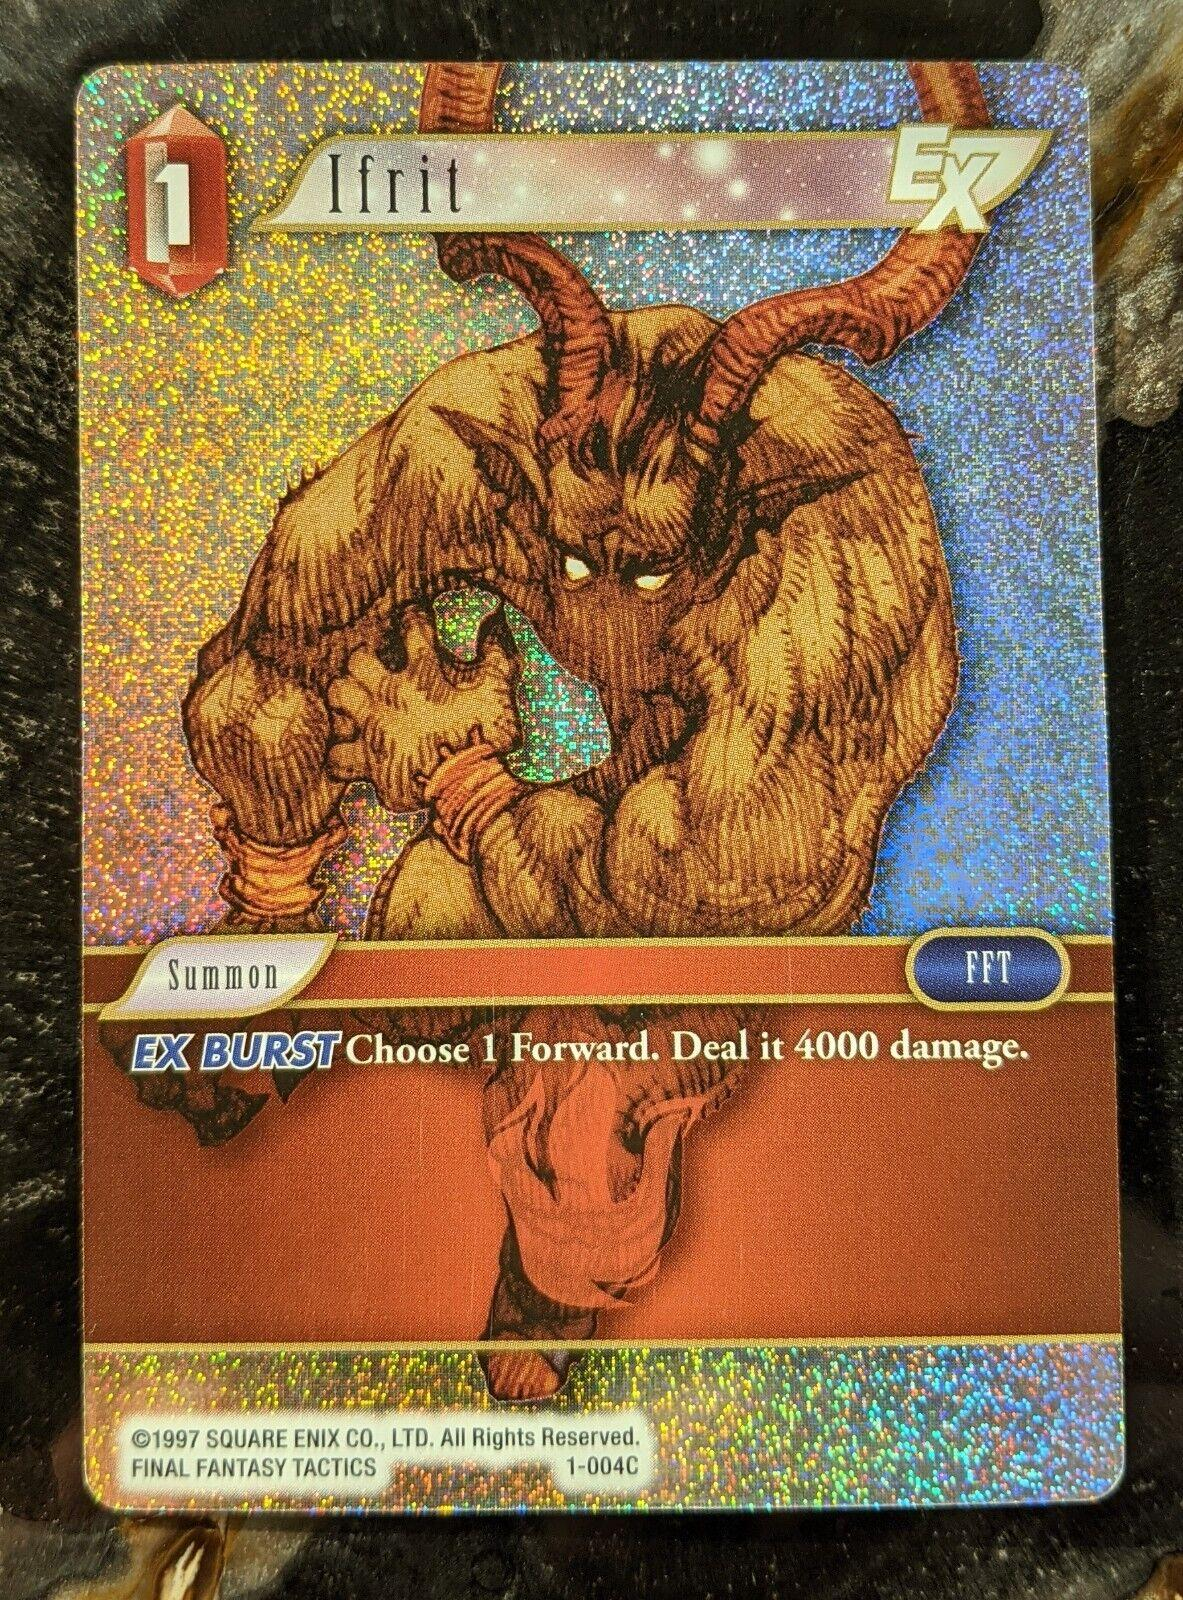

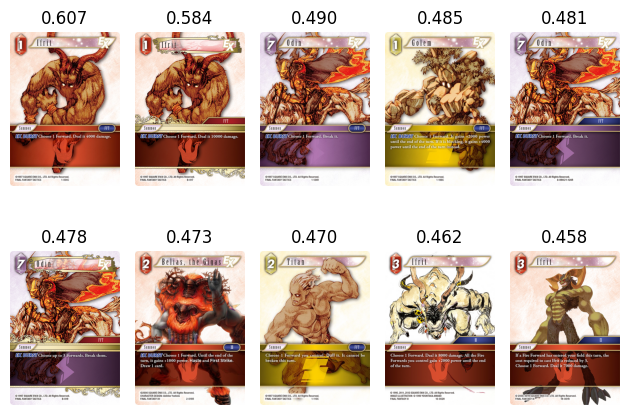

In [30]:
img, plt = find_similar_image(DATA_DIR / "test" / "5.jpg")
img

In [31]:
plt.show()

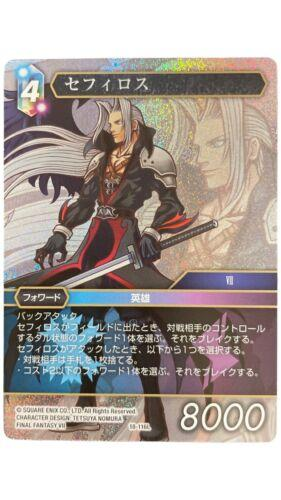

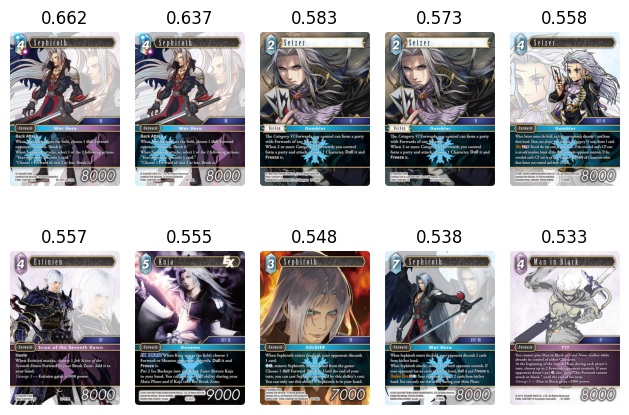

In [32]:
img, plt = find_similar_image(DATA_DIR / "test" / "32.jpg")
img

In [18]:
plt.show()